# Exploratory Data Analysis

## Project

E-Commerce Sales Intelligence Platform

### Objective

Analyze customer behavior, sales performance, delivery operations, and seller performance to generate actionable business insights.

In [14]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load data
data_path = Path("../data/processed")

master_df = pd.read_csv(
    data_path / "master_analytics_table.csv",
    parse_dates=[
        "shipping_limit_date",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

# Quick verification
master_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,seller_zip_code_prefix,seller_city,seller_state,total_payment_value,payment_installments,payment_methods,review_score,review_count,item_revenue,freight_percentage
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,27277,volta redonda,SP,72.19,2.0,1.0,5.0,1.0,72.19,0.225637
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,3471,sao paulo,SP,259.83,3.0,1.0,4.0,1.0,259.83,0.083076
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,37564,borda da mata,MG,216.87,5.0,1.0,5.0,1.0,216.87,0.089799
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,14403,franca,SP,25.78,2.0,1.0,4.0,1.0,25.78,0.984604
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,87900,loanda,PR,218.04,3.0,1.0,5.0,1.0,218.04,0.090745


In [15]:
kpi_summary = {
    "Total Revenue": master_df["item_revenue"].sum(),
    "Total Orders": master_df["order_id"].nunique(),
    "Total Customers": master_df["customer_unique_id"].nunique(),
    "Total Sellers": master_df["seller_id"].nunique(),
    "Average Order Value": (
        master_df.groupby("order_id")["item_revenue"].sum().mean()
    ),
    "Average Review Score": master_df["review_score"].mean()
}

kpi_df = pd.DataFrame(
    kpi_summary.items(),
    columns=["Metric", "Value"]
)

kpi_df

,Metric,Value
0,Total Revenue,1.584355e+07
1,Total Orders,9.866600e+04
2,Total Customers,9.542000e+04
3,Total Sellers,3.095000e+03
4,Average Order Value,1.605776e+02
5,Average Review Score,4.033128e+00


In [16]:
kpi_df = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Sellers",
        "Average Order Value",
        "Average Review Score"
    ],
    "Value": [
        f"${kpi_summary['Total Revenue']:,.2f}",
        f"{kpi_summary['Total Orders']:,}",
        f"{kpi_summary['Total Customers']:,}",
        f"{kpi_summary['Total Sellers']:,}",
        f"${kpi_summary['Average Order Value']:,.2f}",
        f"{kpi_summary['Average Review Score']:.2f}"
    ]
})

kpi_df

,Metric,Value
0,Total Revenue,"$15,843,553.24"
1,Total Orders,"98,666"
2,Total Customers,"95,420"
3,Total Sellers,"3,095"
4,Average Order Value,$160.58
5,Average Review Score,4.03


# Executive Summary

## Initial Findings

The platform processed over **99,000 orders** from nearly **100,000 customers**, generating millions in revenue.



In [17]:
category_revenue = (
    master_df
    .groupby("product_category_name_english", as_index=False)
    .agg(
        Total_Revenue=("item_revenue", "sum"),
        Orders=("order_id", "nunique")
    )
    .sort_values("Total_Revenue", ascending=False)
)

category_revenue.head(10)

,product_category_name_english,Total_Revenue,Orders
43,health_beauty,1441248.07,8836
70,watches_gifts,1305541.61,5624
7,bed_bath_table,1241681.72,9417
65,sports_leisure,1156656.48,7720
15,computers_accessories,1059272.40,6689
39,furniture_decor,902511.79,6449
49,housewares,778397.77,5884
20,cool_stuff,719329.95,3632
5,auto,685384.32,3897
42,garden_tools,584219.21,3518


In [18]:
category_revenue["Total_Revenue"] = (
    category_revenue["Total_Revenue"]
    .round(2)
)

category_revenue.head(10)

,product_category_name_english,Total_Revenue,Orders
43,health_beauty,1441248.07,8836
70,watches_gifts,1305541.61,5624
7,bed_bath_table,1241681.72,9417
65,sports_leisure,1156656.48,7720
15,computers_accessories,1059272.40,6689
39,furniture_decor,902511.79,6449
49,housewares,778397.77,5884
20,cool_stuff,719329.95,3632
5,auto,685384.32,3897
42,garden_tools,584219.21,3518


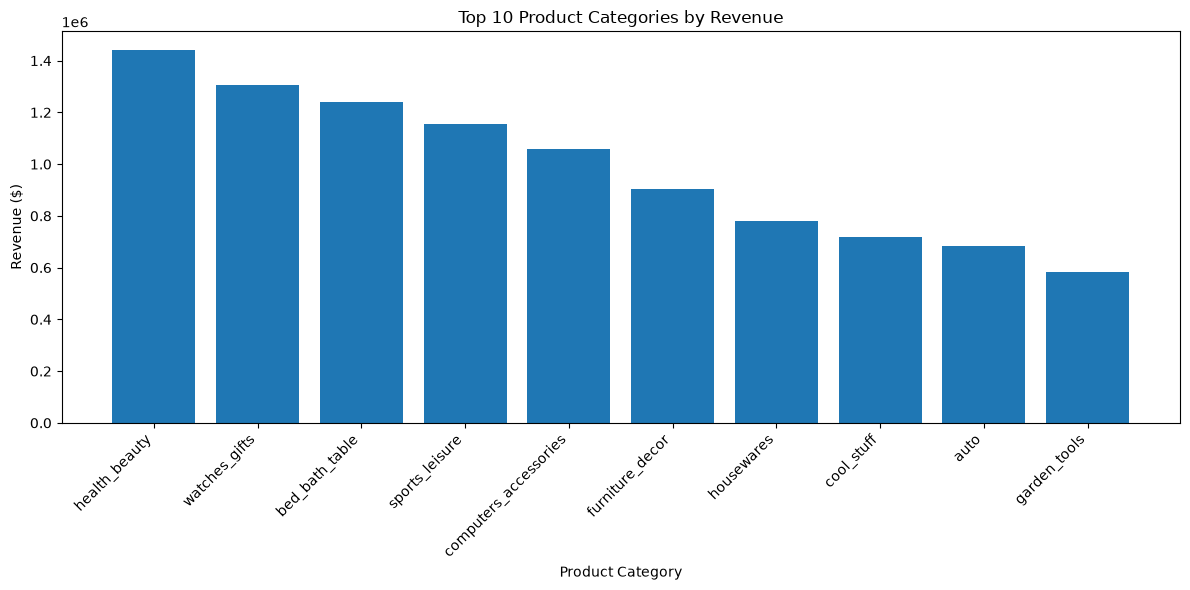

In [19]:
top10 = category_revenue.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top10["product_category_name_english"],
    top10["Total_Revenue"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Product Category")
plt.ylabel("Revenue ($)")
plt.title("Top 10 Product Categories by Revenue")

plt.tight_layout()
plt.show()

## Business Insight

The Health & Beauty category generated the highest total revenue, followed by Watches & Gifts and Bed, Bath & Table.

These categories appear to be the primary revenue drivers for the business. Management may consider prioritizing inventory availability, promotional campaigns, and supplier relationships for these categories to maintain or increase sales performance.

However, high revenue alone does not necessarily indicate high profitability or customer satisfaction. Additional analyses involving profit margins, delivery performance, and customer review scores are needed before making strategic decisions.

#Business Question
Do customers give lower ratings when deliveries are late?

In [20]:
master_df[["is_late_delivery", "review_score"]].head()

,is_late_delivery,review_score
0,False,5.0
1,False,4.0
2,False,5.0
3,False,4.0
4,False,5.0


In [21]:
delivery_reviews = (
    master_df
    .groupby("is_late_delivery", as_index=False)
    .agg(
        Average_Review=("review_score", "mean"),
        Orders=("order_id", "nunique")
    )
)

delivery_reviews

,is_late_delivery,Average_Review,Orders
0,False,4.153360,92131
1,True,2.257411,6535


In [22]:
delivery_reviews["Average_Review"] = (
    delivery_reviews["Average_Review"]
    .round(2)
)

delivery_reviews

,is_late_delivery,Average_Review,Orders
0,False,4.15,92131
1,True,2.26,6535


In [24]:
delivery_reviews_plot = delivery_reviews.copy()

delivery_reviews_plot["Delivery Status"] = (
    delivery_reviews_plot["is_late_delivery"]
    .map({
        False: "On Time",
        True: "Late"
    })
)

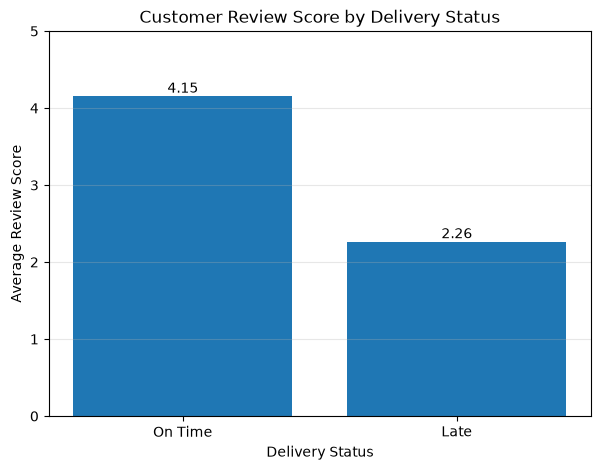

In [26]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    delivery_reviews_plot["Delivery Status"],
    delivery_reviews_plot["Average_Review"]
)

plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.title("Customer Review Score by Delivery Status")

plt.ylim(0,5)

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}",
        ha="center"
    )

plt.show()

## Business Insight

Customers whose orders were delivered on time reported substantially higher review scores (4.15) compared to customers whose deliveries were late (2.26).

Although this analysis does not establish causation, it indicates a strong relationship between delivery performance and customer satisfaction.

Improving on-time delivery rates may help increase customer satisfaction and strengthen customer retention.

## Business Question
Who are our highest-performing sellers, and do they also receive the best customer reviews?

In [27]:
seller_performance = (
    master_df
    .groupby("seller_id", as_index=False)
    .agg(
        Total_Revenue=("item_revenue", "sum"),
        Total_Orders=("order_id", "nunique"),
        Average_Review=("review_score", "mean")
    )
)

seller_performance["Average_Review"] = (
    seller_performance["Average_Review"]
    .round(2)
)

seller_performance = seller_performance.sort_values(
    "Total_Revenue",
    ascending=False
)

seller_performance.head(10)

,seller_id,Total_Revenue,Total_Orders,Average_Review
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70,1132,4.12
1535,7c67e1448b00f6e969d365cea6b010ab,239536.44,982,3.34
1013,53243585a1d6dc2643021fd1853d8905,235856.68,358,4.08
881,4a3ca9315b744ce9f8e9374361493884,235539.96,1806,3.80
3024,fa1c13f2614d7b5c4749cbc52fecda94,204084.73,585,4.34
2643,da8622b14eb17ae2831f4ac5b9dab84a,185192.32,1314,4.06
1560,7e93a43ef30c4f03f38b393420bc753a,182754.05,336,4.21
192,1025f0e2d44d7041d6cf58b6550e0bfa,172860.69,915,3.85
1505,7a67c85e85bb2ce8582c35f2203ad736,162648.38,1160,4.23
1824,955fee9216a65b617aa5c0531780ce60,160602.68,1287,4.05


In [28]:
seller_performance.head()


,seller_id,Total_Revenue,Total_Orders,Average_Review
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70,1132,4.12
1535,7c67e1448b00f6e969d365cea6b010ab,239536.44,982,3.34
1013,53243585a1d6dc2643021fd1853d8905,235856.68,358,4.08
881,4a3ca9315b744ce9f8e9374361493884,235539.96,1806,3.80
3024,fa1c13f2614d7b5c4749cbc52fecda94,204084.73,585,4.34


In [29]:
seller_performance[["Total_Revenue", "Average_Review"]].corr()

,Total_Revenue,Average_Review
Total_Revenue,1.000000,0.020616
Average_Review,0.020616,1.000000


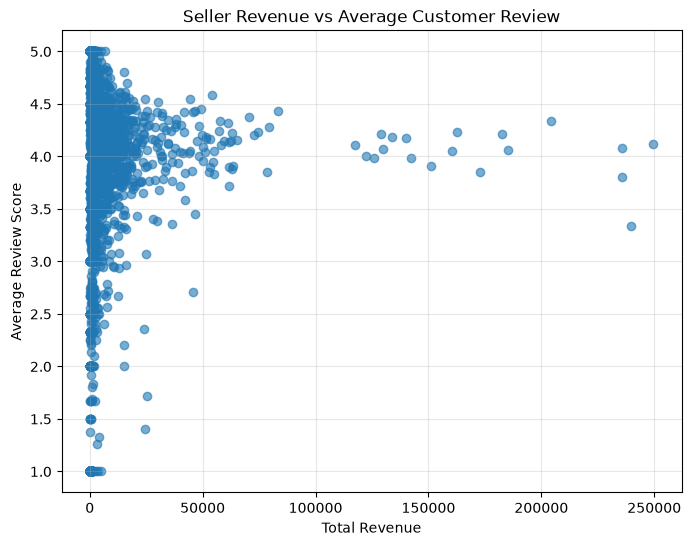

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    seller_performance["Total_Revenue"],
    seller_performance["Average_Review"],
    alpha=0.6
)

plt.xlabel("Total Revenue")
plt.ylabel("Average Review Score")
plt.title("Seller Revenue vs Average Customer Review")

plt.grid(alpha=0.3)

plt.show()

## Business Insight

The correlation between seller revenue and average customer review score was **0.02**, indicating virtually no linear relationship.

This suggests that sellers generating the highest revenue are not necessarily the ones receiving the highest customer ratings. Revenue and customer satisfaction appear to represent different dimensions of seller performance.

Organizations should therefore evaluate sellers using multiple performance metrics rather than relying solely on revenue.

## Business Question
Are customers who experience a late delivery less likely to place another order?


In [32]:
customer_summary = (
    master_df
    .groupby("customer_unique_id", as_index=False)
    .agg(
        Total_Orders=("order_id", "nunique"),
        Had_Late_Delivery=("is_late_delivery", "max")
    )
)

customer_summary.head(10)

,customer_unique_id,Total_Orders,Had_Late_Delivery
0,0000366f3b9a7992bf8c76cfdf3221e2,1,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,False
2,0000f46a3911fa3c0805444483337064,1,False
3,0000f6ccb0745a6a4b88665a16c9f078,1,False
4,0004aac84e0df4da2b147fca70cf8255,1,False
5,0004bd2a26a76fe21f786e4fbd80607f,1,False
6,00050ab1314c0e55a6ca13cf7181fecf,1,False
7,00053a61a98854899e70ed204dd4bafe,1,False
8,0005e1862207bf6ccc02e4228effd9a0,1,False
9,0005ef4cd20d2893f0d9fbd94d3c0d97,1,True


In [33]:
customer_summary["Repeat_Customer"] = (
    customer_summary["Total_Orders"] > 1
)

customer_summary.head()

,customer_unique_id,Total_Orders,Had_Late_Delivery,Repeat_Customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,False,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,False,False
2,0000f46a3911fa3c0805444483337064,1,False,False
3,0000f6ccb0745a6a4b88665a16c9f078,1,False,False
4,0004aac84e0df4da2b147fca70cf8255,1,False,False


In [34]:
retention_analysis = (
    customer_summary
    .groupby("Had_Late_Delivery", as_index=False)
    .agg(
        Customers=("customer_unique_id", "count"),
        Repeat_Customers=("Repeat_Customer", "sum")
    )
)

retention_analysis["Repeat_Rate"] = (
    retention_analysis["Repeat_Customers"]
    / retention_analysis["Customers"]
    * 100
).round(2)

retention_analysis

,Had_Late_Delivery,Customers,Repeat_Customers,Repeat_Rate
0,False,88921,2600,2.92
1,True,6499,313,4.82


## "The initial analysis produced a counterintuitive result. After reviewing the methodology, I determined that customers may have become repeat purchasers before experiencing a late delivery. Therefore, the analysis does not establish whether late delivery influences future purchasing behavior. A revised, time-aware analysis is required."

## Business Question
How have sales changed over time?

In [36]:
monthly_sales = (
    master_df
    .groupby(
        pd.Grouper(
            key="order_purchase_timestamp",
            freq="ME"
        ),
        as_index=False
    )
    .agg(
        Total_Revenue=("item_revenue", "sum"),
        Orders=("order_id", "nunique")
    )
)

monthly_sales.head()

,order_purchase_timestamp,Total_Revenue,Orders
0,2016-09-30,354.75,3
1,2016-10-31,56808.84,308
2,2016-11-30,0.00,0
3,2016-12-31,19.62,1
4,2017-01-31,137188.49,789


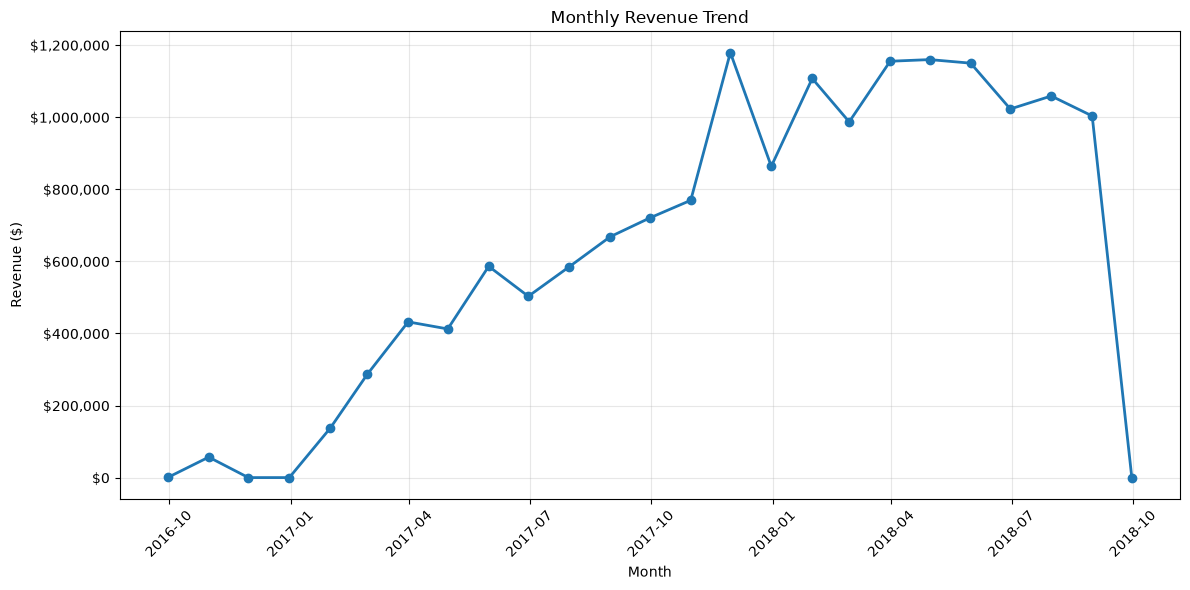

In [39]:
import matplotlib.ticker as mtick

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["order_purchase_timestamp"],
    monthly_sales["Total_Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
monthly_sales.tail()

,order_purchase_timestamp,Total_Revenue,Orders
20,2018-05-31,1149781.82,6853
21,2018-06-30,1022677.11,6160
22,2018-07-31,1058728.03,6273
23,2018-08-31,1003308.47,6452
24,2018-09-30,166.46,1


## Business insights
Monthly revenue showed a strong upward trend from early 2017 through most of 2018, indicating significant business growth. Revenue remained consistently above $1 million per month during much of 2018, suggesting that the platform had reached a more mature stage. The sharp decline in the final month is likely due to incomplete data rather than an actual decrease in sales and should not be interpreted as a business downturn.

## Business Question
Was revenue growth driven by an increase in the number of orders?

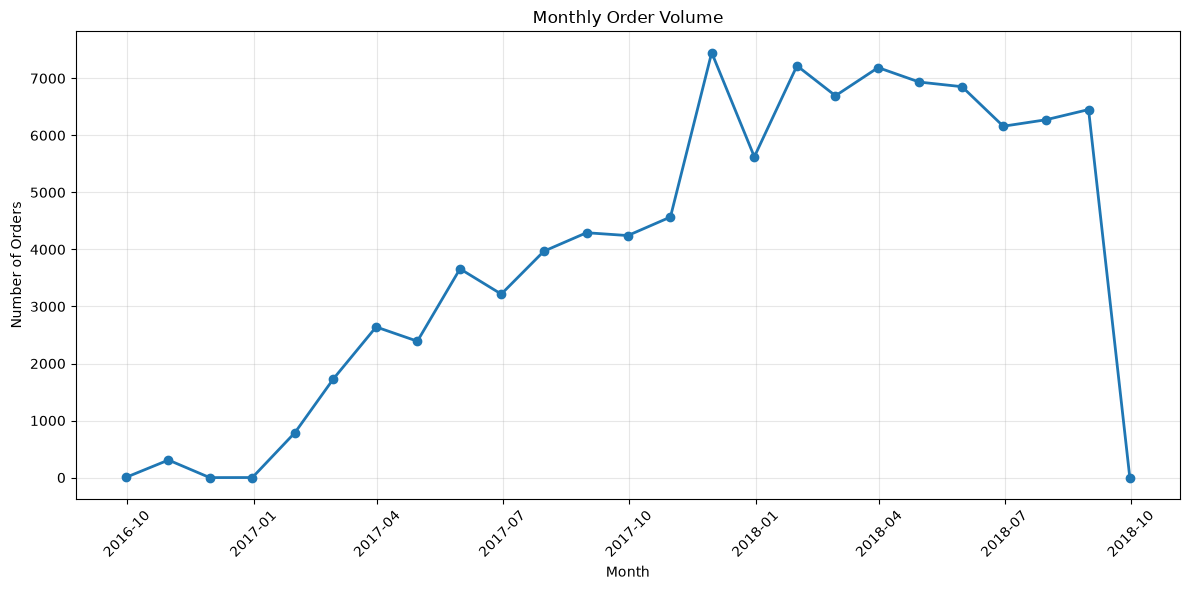

In [40]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["order_purchase_timestamp"],
    monthly_sales["Orders"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Business Question:
Did customers start spending more per order?

In [42]:
monthly_sales["Average_Order_Value"] = (
    monthly_sales["Total_Revenue"]
    / monthly_sales["Orders"]
)

monthly_sales.head(10)

,order_purchase_timestamp,Total_Revenue,Orders,Average_Order_Value
0,2016-09-30,354.75,3,118.250000
1,2016-10-31,56808.84,308,184.444286
2,2016-11-30,0.00,0,NaN
3,2016-12-31,19.62,1,19.620000
4,2017-01-31,137188.49,789,173.876413
5,2017-02-28,286280.62,1733,165.193664
6,2017-03-31,432048.59,2641,163.592802
7,2017-04-30,412422.24,2391,172.489435
8,2017-05-31,586190.95,3660,160.161462
9,2017-06-30,502963.04,3217,156.345365


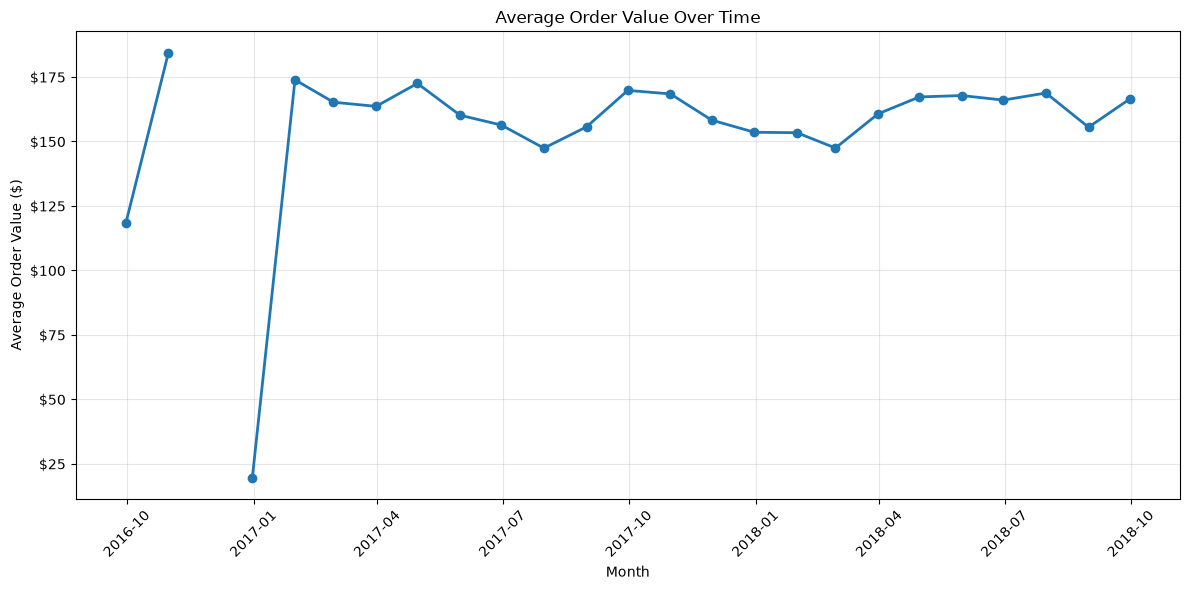

In [43]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["order_purchase_timestamp"],
    monthly_sales["Average_Order_Value"],
    marker="o",
    linewidth=2
)

plt.title("Average Order Value Over Time")
plt.xlabel("Month")
plt.ylabel("Average Order Value ($)")

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)

plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Business Insight
Monthly Average Order Value (AOV) remained relatively stable between approximately $150 and $170 throughout most of the observation period. While there were fluctuations during the earliest months of the dataset, these are likely due to a very small number of transactions. Because AOV remained consistent while total revenue increased significantly, the growth in revenue appears to have been driven primarily by higher order volume rather than larger purchases per order.

## Business Question
Which months consistently generate the highest revenue and order volume?

In [44]:
monthly_seasonality = (
    master_df
    .groupby("month_name", as_index=False)
    .agg(
        Total_Revenue=("item_revenue", "sum"),
        Total_Orders=("order_id", "nunique")
    )
)

In [45]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_seasonality["month_name"] = pd.Categorical(
    monthly_seasonality["month_name"],
    categories=month_order,
    ordered=True
)

monthly_seasonality = (
    monthly_seasonality
    .sort_values("month_name")
)

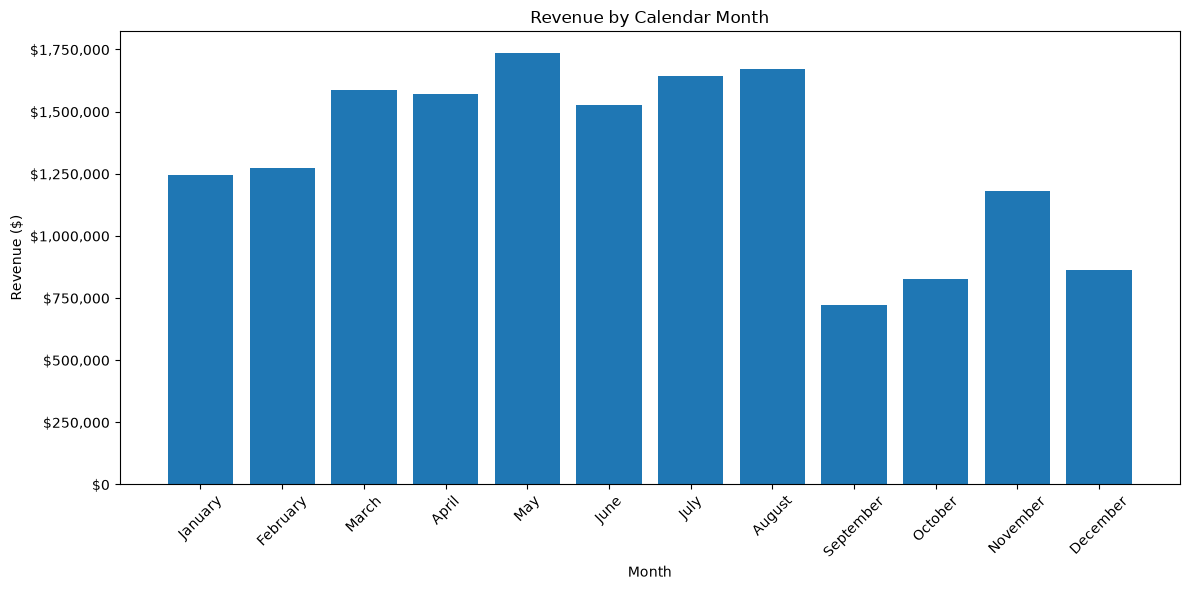

In [46]:
plt.figure(figsize=(12,6))

plt.bar(
    monthly_seasonality["month_name"],
    monthly_seasonality["Total_Revenue"]
)

plt.title("Revenue by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [47]:
seasonality = (
    master_df
    .groupby(
        ["order_year", "month_name"],
        as_index=False
    )
    .agg(
        Monthly_Revenue=("item_revenue", "sum"),
        Monthly_Orders=("order_id", "nunique")
    )
)

seasonality.head()

,order_year,month_name,Monthly_Revenue,Monthly_Orders
0,2016,December,19.62,1
1,2016,October,56808.84,308
2,2016,September,354.75,3
3,2017,April,412422.24,2391
4,2017,August,668204.60,4293


In [49]:
avg_monthly_revenue = (
    seasonality
    .groupby("month_name", as_index=False)
    .agg(
        Average_Revenue=("Monthly_Revenue", "mean"),
        Average_Orders=("Monthly_Orders", "mean")
    )
)

avg_monthly_revenue["month_name"] = pd.Categorical(
    avg_monthly_revenue["month_name"],
    categories=month_order,
    ordered=True
)

avg_monthly_revenue = (
    avg_monthly_revenue
    .sort_values("month_name")
)

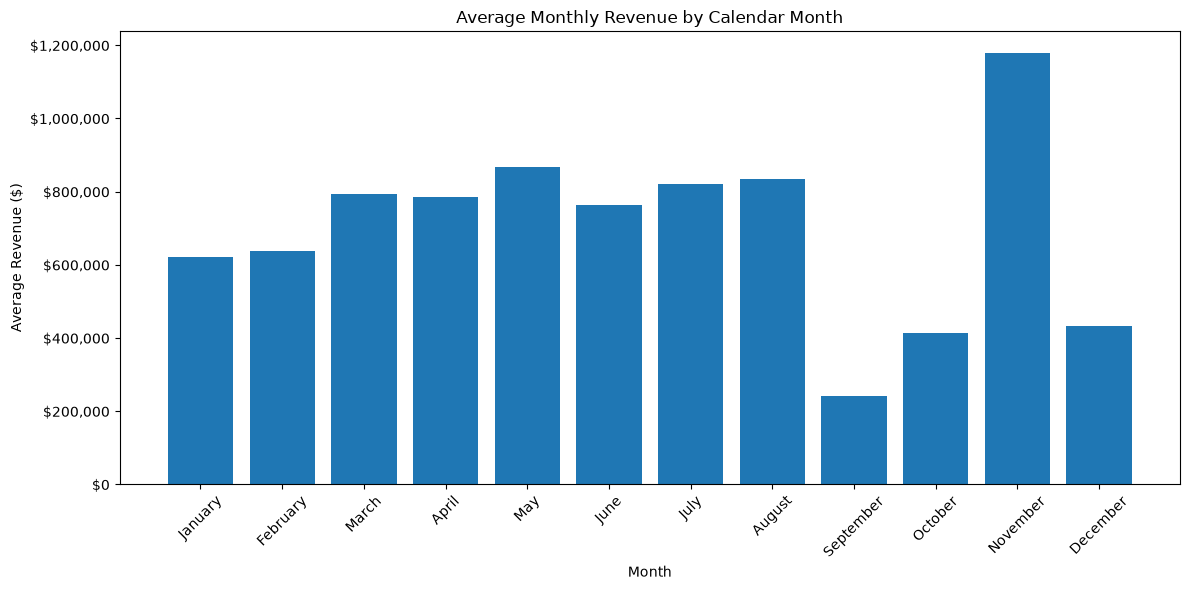

In [50]:
plt.figure(figsize=(12,6))

plt.bar(
    avg_monthly_revenue["month_name"],
    avg_monthly_revenue["Average_Revenue"]
)

plt.title("Average Monthly Revenue by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue ($)")

ax = plt.gca()
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("${x:,.0f}")
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Business Question
Which business metrics tend to move together?

In [53]:
correlation_data = master_df[
    [
        "price",
        "freight_value",
        "item_revenue",
        "delivery_days",
        "delivery_delay_days",
        "review_score"
    ]
]

correlation_data.head()

correlation_matrix = correlation_data.corr()

correlation_matrix

,price,freight_value,item_revenue,delivery_days,delivery_delay_days,review_score
price,1.000000,0.414204,0.997151,0.062290,-0.003596,-0.004081
freight_value,0.414204,1.000000,0.481681,0.214631,-0.040242,-0.036363
item_revenue,0.997151,0.481681,1.000000,0.077777,-0.006800,-0.006960
delivery_days,0.062290,0.214631,0.077777,1.000000,0.597315,-0.304867
delivery_delay_days,-0.003596,-0.040242,-0.006800,0.597315,1.000000,-0.229265
review_score,-0.004081,-0.036363,-0.006960,-0.304867,-0.229265,1.000000


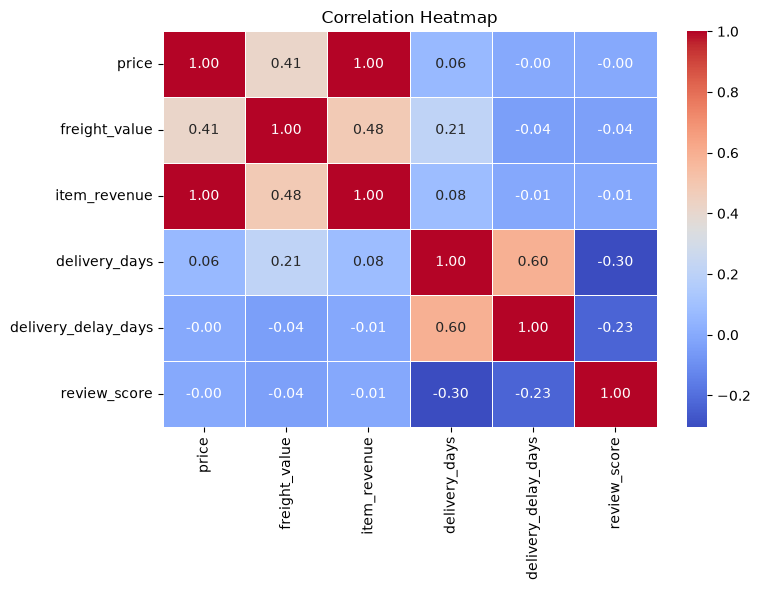

In [55]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

## Business Insights
The correlation analysis identified several meaningful relationships among business metrics. Delivery days and delivery delays showed a moderate positive correlation (0.60), indicating that longer shipping times are associated with an increased likelihood of late deliveries. Both delivery duration (-0.30) and delivery delays (-0.23) exhibited negative correlations with customer review scores, suggesting that slower deliveries are associated with lower customer satisfaction. Product price showed an almost perfect correlation with item revenue, which is expected because revenue is primarily driven by product price. Overall, the analysis highlights logistics performance as a key factor associated with customer experience.